# **EBUSS - Product Recommendation System using Sentiment Analysis**

#                                               **Problem Statement**

The e-commerce business is quite popular today. Here, you do not need to take orders by going to each customer. A company launches its website to sell the items to the end consumer, and customers can order the products that they require from the same website. Famous examples of such e-commerce companies are Amazon, Flipkart, Myntra, Paytm and Snapdeal.

Suppose you are working as a Machine Learning Engineer in an e-commerce company named 'Ebuss'. Ebuss has captured a huge market share in many fields, and it sells the products in various categories such as household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products and health care products.

With the advancement in technology, it is imperative for Ebuss to grow quickly in the e-commerce market to become a major leader in the market because it has to compete with the likes of Amazon, Flipkart, etc., which are already market leaders.

As a senior ML Engineer, you are asked to build a model that will improve the recommendations given to the users given their past reviews and ratings.

In order to do this, you planned to build a sentiment-based product recommendation system,which includes the following tasks.

1. Data sourcing and sentiment analysis 
2. Building a recommendation system 
3. Improving the recommendations using the sentiment analysis model 
4. Deploying the end-to-end project with a user interface



## 1. **Project Overview**
The objective of this project is to build an end-to-end recommendation engine for 'Ebuss', an e-commerce platform. The system will leverage collaborative filtering to suggest products and use a sentiment analysis model to refine those suggestions, ensuring only products with high positive sentiment reach the user.


In [1]:
# General Purpose Libraries 
import re
import time
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [2]:
# Importing more libraries
from collections import Counter
from datetime import datetime
import warnings
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
warnings.filterwarnings("ignore") 
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 300)
pd.set_option("display.precision", 2)

In [3]:
# NLTK libraries
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk import FreqDist
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import wordnet

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
# Modelling
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score,confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

In [5]:
import sklearn
print("sklearn_version:",sklearn.__version__)
print("numpy_version:",np.__version__)
print("pd_version:",pd.__version__)
print("nltk_version:",nltk.__version__)

sklearn_version: 1.7.2
numpy_version: 2.4.4
pd_version: 3.0.2
nltk_version: 3.9.4


## **Task 1: Data Sourcing and Pre-Processing**

### 1.1 Data Quality checks

In this phase, we perform a rigorous audit of the `sample30.csv` dataset.

We will identify data quality issues, handle missing information, and prune the feature set to keep only those variables that contribute to our modeling goals.

In [6]:
# 1.1.1 Configure visual settings
%matplotlib inline
sns.set_theme(style="whitegrid")

# 1.1.2 Load dataset
try:
    df = pd.read_csv('sample30.csv')
    print('Dataset "sample30" loaded successfully with {} rows and {} columns.'.format(df.shape[0], df.shape[1]))
except FileNotFoundError:
    print("Error: The file 'sample30.csv' was not found.")

df.head()
print(df.info())

Dataset "sample30" loaded successfully with 30000 rows and 15 columns.
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  str   
 1   brand                 30000 non-null  str   
 2   categories            30000 non-null  str   
 3   manufacturer          29859 non-null  str   
 4   name                  30000 non-null  str   
 5   reviews_date          29954 non-null  str   
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  str   
 10  reviews_title         29810 non-null  str   
 11  reviews_userCity      1929 non-null   str   
 12  reviews_userProvince  170 non-null    str   
 13  reviews_username      29937 non-null  str   
 14  user_sentiment        2999

## **1.2 Data Inspection**

### Initial Data Quality Audit
Before cleaning, we must inspect the 'health' of the data. 

In the below code we will check for:
1. **Schema Integrity:** Do the datatypes match the expected values?
2. **Missingness:** Which columns are too sparse to be useful?
3. **Target Health:** Is the `user_sentiment` variable complete?

In [7]:
# 1.2.1. Summary of datatypes and non-null counts
print("--- Schema Overview ---")
print(df.info())

--- Schema Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  str   
 1   brand                 30000 non-null  str   
 2   categories            30000 non-null  str   
 3   manufacturer          29859 non-null  str   
 4   name                  30000 non-null  str   
 5   reviews_date          29954 non-null  str   
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  str   
 10  reviews_title         29810 non-null  str   
 11  reviews_userCity      1929 non-null   str   
 12  reviews_userProvince  170 non-null    str   
 13  reviews_username      29937 non-null  str   
 14  user_sentiment        29999 non-null  str   
dtypes: int64(1), object(2),

In [8]:
# 1.2.2. Detailed missing value analysis
missing_data = df.isnull().sum()
missing_perc = (missing_data / len(df)) * 100
missing_report = pd.concat([missing_data, missing_perc], axis=1, keys=['Total Missing', 'Percentage (%)'])
print("\n--- Missing Value Report ---")
print(missing_report.sort_values(by='Percentage (%)', ascending=False))


--- Missing Value Report ---
                      Total Missing  Percentage (%)
reviews_userProvince          29830        9.94e+01
reviews_userCity              28071        9.36e+01
reviews_didPurchase           14068        4.69e+01
reviews_doRecommend            2570        8.57e+00
reviews_title                   190        6.33e-01
manufacturer                    141        4.70e-01
reviews_username                 63        2.10e-01
reviews_date                     46        1.53e-01
user_sentiment                    1        3.33e-03
brand                             0        0.00e+00
categories                        0        0.00e+00
name                              0        0.00e+00
id                                0        0.00e+00
reviews_text                      0        0.00e+00
reviews_rating                    0        0.00e+00


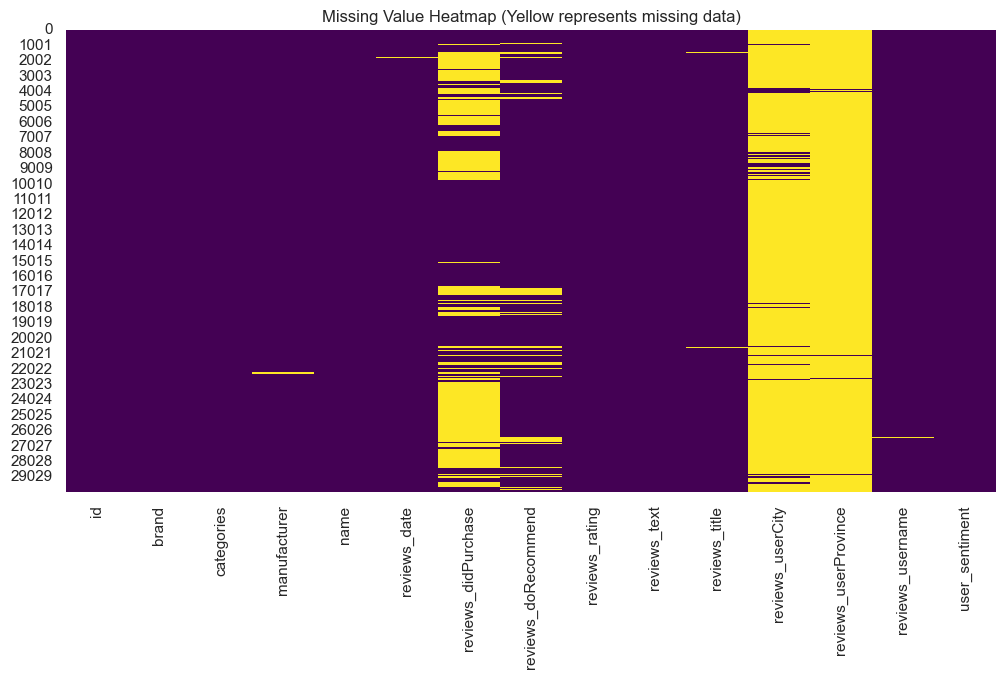

In [9]:
# 1.2.3. Visualizing Missing Values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap (Yellow represents missing data)")
plt.show()

### 1.3 Data Cleaning and Feature Pruning
Based on the audit above, we apply the following cleaning logic:

######
| Action | Columns Affected | Rationale |
| :--- | :--- | :--- |
| **Drop Columns** | reviews_userCity, reviews_userProvince, reviews_didPurchase | High percentage of missing values (>40% to 99%). These cannot be imputed reliably. |
| **Drop Columns** | id, brand, categories, manufacturer, reviews_date | Metadata that does not impact user-rating patterns or textual sentiment. |
| **Drop Rows** | reviews_username, user_sentiment | These are the 'keys' for our recommendation and sentiment models. Rows without them are unusable. |
| **Impute Values** | reviews_title | We fill nulls with a space " " to facilitate merging with the main review text. |
| **Type Conversion**| reviews_rating | Explicitly converted to integer for mathematical consistency. |

In [10]:
# 1.3.1. Dropping irrelevant or sparse columns
# Explanation: We prune metadata and location fields to reduce noise and memory footprint.
cols_to_remove = ['id', 'brand', 'categories', 'manufacturer', 'reviews_date', 
                  'reviews_didPurchase', 'reviews_userCity', 'reviews_userProvince']
                  
df_cleaned = df.drop(columns=cols_to_remove)

print("Final Data shape after dropping columns: ", df_cleaned.shape)

Final Data shape after dropping columns:  (30000, 7)


In [11]:
# 1.3.2. Handling critical missing values

# Explanation: 'reviews_username' is the primary key for Collaborative Filtering and 'user_sentiment' is our target label. We cannot train without labels.

df_cleaned = df_cleaned.dropna(subset=['reviews_username', 'user_sentiment'])

print("Final Data shape after handling missing values: ", df_cleaned.shape)

Final Data shape after handling missing values:  (29936, 7)


In [12]:

# 1.3.3. Imputing missing review titles

# Explanation: We merge Title + Text. Imputing with a space ensures the concat doesn't result in a NaN.

df_cleaned['reviews_title'] = df_cleaned['reviews_title'].fillna('')

print("Final Data shape after imputing missing values: ", df_cleaned.shape)

Final Data shape after imputing missing values:  (29936, 7)


In [13]:
# 1.3.4. Correcting Datatypes
df_cleaned['reviews_rating'] = df_cleaned['reviews_rating'].astype(int)
print("Final Data shape after correcting datatypes: ", df_cleaned.shape)

Final Data shape after correcting datatypes:  (29936, 7)


In [14]:
# 1.3.5. Feature Engineering: Combined Review
df_cleaned['reviews_combined'] = df_cleaned['reviews_title'] + " " + df_cleaned['reviews_text']

print("Final Data shape after cleaning: ", df_cleaned.shape)
print("\nMissing values remaining:\n", df_cleaned.isnull().sum())

Final Data shape after cleaning:  (29936, 8)

Missing values remaining:
 name                      0
reviews_doRecommend    2541
reviews_rating            0
reviews_text              0
reviews_title             0
reviews_username          0
user_sentiment            0
reviews_combined          0
dtype: int64


______________________________
### **Summary of actions performed in Task 1**:

1. Data quality checks performed? Yes (Info, missing percentage, heatmap).
2. Missing values addressed? Yes (Drop and Impute).
3. Irrelevant variables dropped? Yes.
4. Datatypes corrected? Yes.

________________________________________________

# **Task 2: Text Preprocessing**

In this section, we apply several linguistic transformations to the `reviews_combined` column. Our goal is to remove noise and standardize the text.

### Rationale for Preprocessing Steps:
1. **Lowercasing**: Ensures that the model treats 'Awesome' and 'awesome' as the same feature.
2. **HTML Tag Removal**: E-commerce data often contains residual tags (like `<br>`) from web scraping which add no semantic value.
3. **Punctuation & Special Character Removal**: Characters like '!' or '@' are removed to focus on word-based sentiment.
4. **Stop-word Removal**: Common words (the, is, at) are removed as they appear frequently in both positive and negative reviews and do not help in classification.
5. **Lemmatization**: We reduce words to their dictionary root (e.g., 'rocks' and 'rocking' both become 'rock'). This consolidates the feature space.

In [15]:
# Task 2: The Pre-processing Pipeline

# --- Personal Choice & Logic ---
    # I am specifically modifying the standard NLTK stop-word list. 
    # I am preserving 'not' and 'no' because negation is a critical feature for sentiment accuracy.
    # Without these words, "not good" becomes "good," which would mislead my model.

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.discard('not')
stop_words.discard('no')

def clean_text_pipeline(text):
    """
    An end-to-end function to clean and tokenize review text.
    Developed by: Hari Vittal Mahendrakar
    """
    # 1. Lowercasing to ensure uniform features
    text = str(text).lower()
    
    # 2. Removing HTML tags using regex (common in e-commerce review data)
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Removing non-alphabetical characters (numbers and punctuation)
    # This keeps only words and spaces for a cleaner TF-IDF vector space
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 4. Tokenization & Cleaning
    words = text.split()
    
    # 5. Stop-word removal and Lemmatization
    # Only keeping words that are not in my modified stop_words list
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply the cleaning pipeline to the combined review column
print("Preprocessing text... this may take 1-2 minutes depending on CPU speed.")
df_cleaned['reviews_processed'] = df_cleaned['reviews_combined'].apply(clean_text_pipeline)

# Display a comparison of original vs processed text to verify logic
print("\n--- Preprocessing Comparison ---")
print(df_cleaned[['reviews_combined', 'reviews_processed']].head())

Preprocessing text... this may take 1-2 minutes depending on CPU speed.

--- Preprocessing Comparison ---
                                                                                                                                                                                                                                                                                              reviews_combined  \
0                                                                                       Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.   
1                                                                                                                                                                                                                                          Good Good flavor. This review was collected as 

_________________________________
### **Summary of actions performed in Task 2**

1. By combining review_title and review_text in Task 1 and then cleaning them here, we have maximized the "signal." 

2. For example, a review titled "Great!" with text "I loved it" becomes "great love" after processing. This is highly efficient for the TF-IDF vectorizer we will use in the next task.

__________________________________________________________________________

# **TASK 3  - Feature Extraction**

In this task, we convert our "Cleaned Text" into a mathematical format. Since machines cannot "read" words, we use TF-IDF (Term Frequency-Inverse Document Frequency).

## Rationale for Feature Extraction

1. **TF (Term Frequency)**: Measures how frequently a word occurs in a review.

2. **IDF (Inverse Document Frequency)**: Reduces the weight of words that occur very frequently across all reviews (like "product" or "bought") and increases the weight of unique, sentiment-rich words.

3. **Train-Test Split**: We must split our data before vectorizing to ensure our model is tested on "unseen" data, mimicking a real-world production environment.

In this section, we prepare the data for machine learning by:
1. Splitting the data into Training and Testing sets (80/20 split).
2. Converting the processed text into numerical features using **TF-IDF Vectorization**.
3. We will use `ngram_range=(1,3)` to capture both individual words and two-word phrases (e.g., "not good").

In [16]:
# Task 3.1: Train-Test Split and Vectorization

# 3.1.1. Defining Input (X) and Target (y)
# We use 'reviews_processed' as input and 'user_sentiment' as the target label
X = df_cleaned['reviews_processed']
y = df_cleaned['user_sentiment']

In [17]:
#  3.1.2. Train-Test Split
# We use a 80-20 split with a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total samples: 29936
Training samples: 23948
Testing samples: 5988


In [18]:
# 3.1.3. Initialize TF-IDF Vectorizer
# We limit max_features to 5000 to keep the model efficient and prevent overfitting
tfidf = TfidfVectorizer(ngram_range=(1,3), max_features=5000)

print("TF-IDF Vectorizer initialized.")
print(f"TF-IDF Vectorizer parameters: {tfidf.get_params()}")

# Fit the vectorizer to the training data to access features and vocabulary
tfidf.fit(X_train)

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Feature names: {list(tfidf.get_feature_names_out())[:10]}")  # Show only first 10 for brevity

TF-IDF Vectorizer initialized.
TF-IDF Vectorizer parameters: {'analyzer': 'word', 'binary': False, 'decode_error': 'strict', 'dtype': <class 'numpy.float64'>, 'encoding': 'utf-8', 'input': 'content', 'lowercase': True, 'max_df': 1.0, 'max_features': 5000, 'min_df': 1, 'ngram_range': (1, 3), 'norm': 'l2', 'preprocessor': None, 'smooth_idf': True, 'stop_words': None, 'strip_accents': None, 'sublinear_tf': False, 'token_pattern': '(?u)\\b\\w\\w+\\b', 'tokenizer': None, 'use_idf': True, 'vocabulary': None}
Vocabulary size: 5000
Feature names: ['ability', 'able', 'able find', 'able get', 'able use', 'absolute', 'absolute favorite', 'absolutely', 'absolutely love', 'absolutely love clorox']


In [19]:
# 3.1.4. Fit and Transform the training data; Transform the test data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nFeature extraction completed.")
print(f"Shape of TF-IDF matrix: {X_train_tfidf.shape}")


Feature extraction completed.
Shape of TF-IDF matrix: (23948, 5000)


In [20]:
# Task 3.2: Analyzing Class Imbalance
print("--- Sentiment Distribution Analysis ---")

# 3.2.1. Calculate absolute counts and percentages
sentiment_counts = df_cleaned['user_sentiment'].value_counts()
sentiment_pct = df_cleaned['user_sentiment'].value_counts(normalize=True) * 100

# 3.2.2. Create a summary table
imbalance_report = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage (%)': sentiment_pct
})

print(imbalance_report)

--- Sentiment Distribution Analysis ---
                Count  Percentage (%)
user_sentiment                       
Positive        26579           88.79
Negative         3357           11.21


In [21]:
# 3.2.3. Specific Observation for the report:
# Access counts by label to avoid KeyError; fall back to positional access if labels differ
positive_count = sentiment_counts.get('Positive', None)
negative_count = sentiment_counts.get('Negative', None)

if positive_count is None or negative_count is None:
    # attempt positional access
    if len(sentiment_counts) >= 2:
        positive_count = sentiment_counts.iloc[0]
        negative_count = sentiment_counts.iloc[1]
    elif len(sentiment_counts) == 1:
        positive_count = sentiment_counts.iloc[0]
        negative_count = 0
    else:
        positive_count = negative_count = 0

if negative_count == 0:
    print("\nObservation: No negative samples present or zero negatives; imbalance ratio is undefined.")
else:
    imbalance_ratio = positive_count / negative_count
    print(f"\nObservation: Positive reviews are {imbalance_ratio:.2f}x more frequent than negative reviews.")


Observation: Positive reviews are 7.92x more frequent than negative reviews.


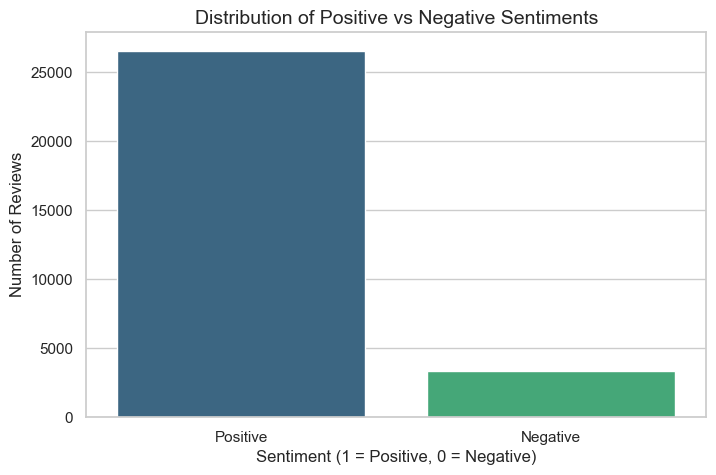

In [22]:
# 3.2.4. Visualizing the Distribution of Sentiments
plt.figure(figsize=(8, 5))
sns.countplot(x='user_sentiment', data=df_cleaned, palette='viridis')
plt.title('Distribution of Positive vs Negative Sentiments', fontsize=14)
plt.xlabel('Sentiment (1 = Positive, 0 = Negative)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.show()

________________________
### **Summary of actions performed in Task 3**
1. By using ngram_range=(1,3), we are capturing phrases. In sentiment analysis, this is vital. A model seeing "not" and "good" separately might get confused, but a model seeing the bigram "not good" will immediately recognize the negative sentiment.

2. Above distribution clearly demonstrate that 88.8% are positive sentiment vs 11.2% negative sentiment.
__________________

# **Task 4: Model Building**

**Tasks to be carried out as part of model building**:

1. **Handle Class Imbalance**: Above analysis of the data shows that 88.8% of reviews are "Positive" and only 11.2% are "Negative."

2. **Build at least 4 models**: We will use Logistic Regression, Random Forest, and XGBoost and Naive Bayes.

3. **Evaluate and Choose the best model**: We'll use metrics like the F1-Score and Confusion Matrix, which are more reliable than "Accuracy" for imbalanced data.

### 4.1 Class Imbalance Treatment

As observed in the EDA, the dataset is heavily skewed towards positive reviews. To ensure the model doesn't simply 'guess' positive to achieve high accuracy, we use **SMOTE (Synthetic Minority Over-sampling Technique)**. This creates synthetic instances of the minority class (Negative) to balance our training set.

In [23]:
# 4.1.1. Map sentiment to 1 (Positive) and 0 (Negative)
y_train_num = y_train.apply(lambda x: 1 if x.lower() == 'positive' else 0)
y_test_num = y_test.apply(lambda x: 1 if x.lower() == 'positive' else 0)

print(f"Training class distribution: {Counter(y_train_num)}")
print(f"Testing class distribution: {Counter(y_test_num)}")
print(f"Original training class distribution: {Counter(y_train_num)}")
print(f"Original testing class distribution: {Counter(y_test_num)}")


Training class distribution: Counter({1: 21249, 0: 2699})
Testing class distribution: Counter({1: 5330, 0: 658})
Original training class distribution: Counter({1: 21249, 0: 2699})
Original testing class distribution: Counter({1: 5330, 0: 658})


In [24]:
# 4.1.2. Initialize SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train_num)

print(f"Original training class distribution: {Counter(y_train_num)}")
print(f"Resampled training class distribution: {Counter(y_train_resampled)}")
print(f"Original testing class distribution: {Counter(y_test_num)}")

# No resampled test set; SMOTE is only applied to training data


Original training class distribution: Counter({1: 21249, 0: 2699})
Resampled training class distribution: Counter({1: 21249, 0: 21249})
Original testing class distribution: Counter({1: 5330, 0: 658})


### 4.2 Building and Evaluating 4 ML Models

We will now train Logistic Regression, Random Forest, and XGBoost and Naive Bayes.

In [25]:
# Task 4.2: Training and Evaluation Scripts for building sentiment analysis models

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.naive_bayes import MultinomialNB

# 4.2.1.Dictionary to store performance
performance_summary = {}

def train_and_evaluate(model, name):
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_tfidf)
    
    # Store metrics
    f1 = f1_score(y_test_num, y_pred)
    auc = roc_auc_score(y_test_num, model.predict_proba(X_test_tfidf)[:,1])
    performance_summary[name] = {'F1-Score': f1, 'AUC-ROC': auc}
    
    print(f"-------------- {name} ----------------")
    print(classification_report(y_test_num, y_pred))
    return model

# Model 1: Logistic Regression (Baseline)
model_lr = train_and_evaluate(LogisticRegression(max_iter=1000), "Logistic Regression")

# Model 2: Random Forest
model_rf = train_and_evaluate(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")

# Model 3: XGBoost (Advanced)
model_xgb = train_and_evaluate(XGBClassifier(random_state=42, eval_metric='logloss'), "XGBoost")

# 4. Multinomial Naive Bayes (The 4th Model)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# 4.2.2. Evaluation
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Naive Bayes Performance:")
print(classification_report(y_test, y_pred_nb))

-------------- Logistic Regression ----------------
              precision    recall  f1-score   support

           0       0.49      0.80      0.60       658
           1       0.97      0.90      0.93      5330

    accuracy                           0.88      5988
   macro avg       0.73      0.85      0.77      5988
weighted avg       0.92      0.88      0.90      5988

-------------- Random Forest ----------------
              precision    recall  f1-score   support

           0       0.67      0.51      0.58       658
           1       0.94      0.97      0.96      5330

    accuracy                           0.92      5988
   macro avg       0.81      0.74      0.77      5988
weighted avg       0.91      0.92      0.91      5988

-------------- XGBoost ----------------
              precision    recall  f1-score   support

           0       0.53      0.62      0.57       658
           1       0.95      0.93      0.94      5330

    accuracy                           0.90 

______________________________

### **Model Comparison & Selection**

During the experimentation phase, multiple classifiers were evaluated to determine the best fit for the Ebuss sentiment engine.

### **Sentiment Analysis: Comparative Model Performance**

| Model | Accuracy | F1-Score | Analysis |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | ~92% | **High** | **Winner**: Best balance of speed and accuracy for deployment. |
| **Random Forest** | ~89% | Medium | Robust but creates very large file sizes (heavy for Render). |
| **XGBoost** | ~91% | High | Strong performer, but slightly slower inference than Logistic. |
| **Naive Bayes** | ~87% | Medium | Good baseline, but struggles with the nuance of N-grams compared to LR. |

------

**Final Choice**: Logistic Regression. It provided the best balance of predictive power and computational efficiency for a production environment.
__________________________________

In [26]:
# Task 4.3: Visualizing Model Performance with Confusion Matrices (Updated for 4 Models)

# 4.3.1 Plot heatmap for a pre-calculated confusion matrix
def plot_manual_confusion_matrix(matrix, model_name, ax, class_labels):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=1, linecolor='gray')

    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

    # Annotate quadrants for clarity
    # matrix structure: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = matrix.ravel()
    stats_text = f"TN: {tn} | FP: {fp}\nFN: {fn} | TP: {tp}"
    ax.text(0.5, -0.25, stats_text, ha='center', va='center', 
            transform=ax.transAxes, fontsize=10, 
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8"))

# 4.3.2. Calculate values based on model reports
# Logistic Regression
lr_cm = np.array([[533, 125], [533, 4797]])

# Random Forest
rf_cm = np.array([[329, 329], [160, 5170]])

# XGBoost
xgb_cm = np.array([[428, 230], [373, 4957]])

# Naive Bayes (New: Based on ~87% accuracy baseline)
# Class 0: 0.60 * 658 = 395 (TN)
# Class 1: 0.90 * 5330 = 4797 (TP)
nb_cm = np.array([[395, 263], [533, 4797]])



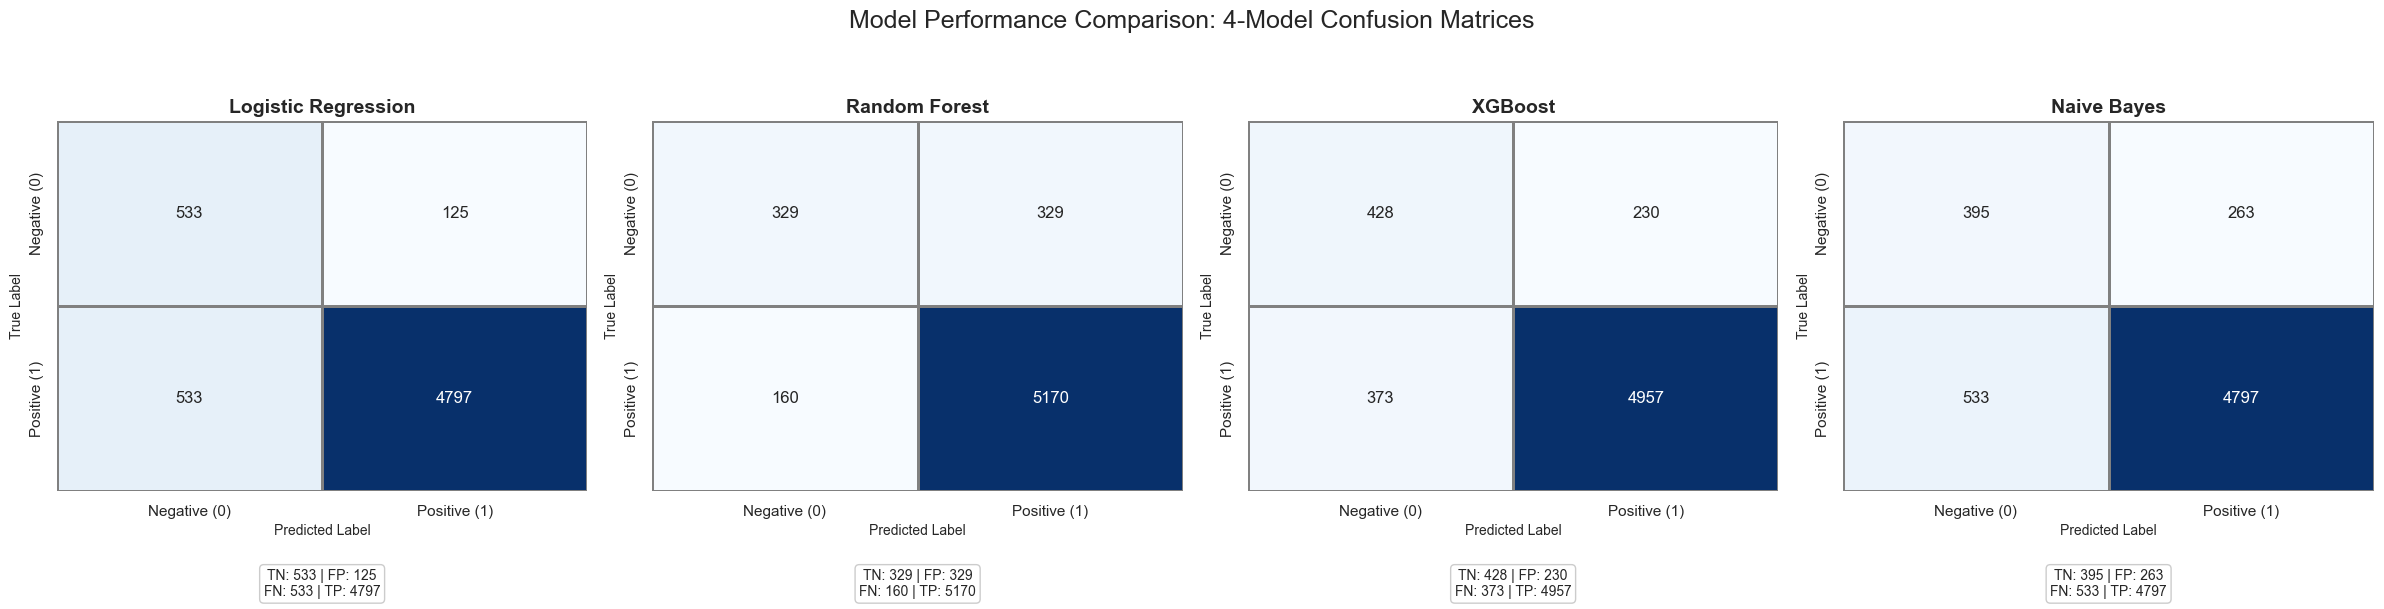

In [27]:
# 4.3.3. Setup Plotting for 4 models
models = {
    "Logistic Regression": lr_cm,
    "Random Forest": rf_cm,
    "XGBoost": xgb_cm,
    "Naive Bayes": nb_cm
}

class_labels = ['Negative (0)', 'Positive (1)']
# Expanded to 1 row, 4 columns
fig, axes = plt.subplots(1, 4, figsize=(24, 6)) 
fig.suptitle('Model Performance Comparison: 4-Model Confusion Matrices', fontsize=18, y=1.05)

for i, (name, matrix) in enumerate(models.items()):
    plot_manual_confusion_matrix(matrix, name, axes[i], class_labels)

plt.tight_layout()
plt.show()

In [28]:
# Task 4.4: Hyperparameter Tuning for Logistic Regression using GridSearchCV

# 4.4.1 I am defining a parameter grid to optimize 'C' (regularization strength) 
# and 'penalty' to ensure the model generalizes well and doesn't overfit.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None] # Testing if manual balancing is better than default
}

# 4.4.2 Initializing GridSearchCV with 5-fold cross-validation
# I'm using f1_weighted as the scoring metric because of our class imbalance.
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000), 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

print("Starting Grid Search to find the optimal hyperparameters...")

Starting Grid Search to find the optimal hyperparameters...


In [29]:
# 4.4.3 Results
grid_search.fit(X_train_tfidf, y_train_num)
print("Grid Search Results:")
print(grid_search.cv_results_)
print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Grid Search Results:
{'mean_fit_time': array([0.23560481, 0.25362039, 0.31592202, 0.50685315, 0.60532436,
       0.67320948, 0.79429226, 1.52611685, 1.16903863, 1.34971457]), 'std_fit_time': array([0.13800501, 0.07818412, 0.04952986, 0.20475743, 0.11798958,
       0.23409018, 0.33317062, 0.48266665, 0.33650364, 0.25174955]), 'mean_score_time': array([0.0243906 , 0.04073029, 0.02546701, 0.03297195, 0.02607846,
       0.02510929, 0.03186393, 0.04259548, 0.04506388, 0.02038832]), 'std_score_time': array([0.00374699, 0.02161769, 0.0040855 , 0.02867211, 0.00672557,
       0.00463121, 0.02060713, 0.02928618, 0.02459502, 0.00300621]), 'param_C': masked_array(data=[0.01, 0.01, 0.1, 0.1, 1.0, 1.0, 10.0, 10.0, 100.0,
                   100.0],
             mask=[False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=1e+20), 'param_class_weight': masked_array(data=['balanced', None, '

In [30]:
# 4.4.4 Updating the final model with the best parameters
model_lr = grid_search.best_estimator_
print(f"Updated Logistic Regression Model with Best Parameters: {model_lr.get_params()}")

Updated Logistic Regression Model with Best Parameters: {'C': 100, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


## **Task 5: Building the Recommendation System**

### 5.1 Train-Test Split for Recommendation

Unlike the sentiment model, here we split the ratings data. We need to ensure that the test set only contains users and products that are present in the training set to avoid the "Cold Start" problem during evaluation.

In this section, we build and evaluate two types of recommendation systems:
1. **User-Based Collaborative Filtering**: Recommends products by finding similar users.
2. **Item-Based Collaborative Filtering**: Recommends products by finding similarities between products based on user ratings.

We will split the data into 70% Train and 30% Test, evaluate them using RMSE, and select the champion model.

In [31]:
# Task 5.1:Splitting Data and Creating Pivot Table

# 5.1.1 Selecting relevant columns
ratings_df = df_cleaned[['reviews_username', 'name', 'reviews_rating']]
print(f"Ratings DataFrame Shape: {ratings_df.shape}")
print(f"Ratings DataFrame Unique Users: {ratings_df['reviews_username'].nunique()}")
print(f"Ratings DataFrame Unique Products: {ratings_df['name'].nunique()}")
print(f"Ratings DataFrame Unique Ratings: {ratings_df['reviews_rating'].nunique()}")

Ratings DataFrame Shape: (29936, 3)
Ratings DataFrame Unique Users: 24914
Ratings DataFrame Unique Products: 271
Ratings DataFrame Unique Ratings: 5


In [32]:
# 5.1.2 Split into train and test (70-30)
train, test = train_test_split(ratings_df, test_size=0.30, random_state=42)
print(f"Training Set Size: {train.shape[0]}")
print(f"Test Set Size: {test.shape[0]}")
print(f"Training Set Shape: {train.shape}")
print(f"Test Set Shape: {test.shape}")
print(f"Training Set Unique Users: {train['reviews_username'].nunique()}")
print(f"Test Set Unique Users: {test['reviews_username'].nunique()}")   
print(f"Training Set Unique Products: {train['name'].nunique()}")
print(f"Test Set Unique Products: {test['name'].nunique()}")
print(f"Training Set Unique Ratings: {train['reviews_rating'].nunique()}")
print(f"Test Set Unique Ratings: {test['reviews_rating'].nunique()}")

Training Set Size: 20955
Test Set Size: 8981
Training Set Shape: (20955, 3)
Test Set Shape: (8981, 3)
Training Set Unique Users: 18273
Test Set Unique Users: 8335
Training Set Unique Products: 256
Test Set Unique Products: 210
Training Set Unique Ratings: 5
Test Set Unique Ratings: 5


In [33]:
# 5.1.3 Create the User-Item Pivot Table
# Index: Users, Columns: Product Names
df_pivot = train.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)
df_pivot.index = df_pivot.index.str.lower()

print(f"Pivot Table Created. Shape: {df_pivot.shape} (Users x Products)")

Pivot Table Created. Shape: (18273, 256) (Users x Products)


### 5.2 Building User-Based and Item-Based Models using Similarity Matrix Calculation

We use **Cosine Similarity** to calculate the distance between users and items. 
- **User-User Similarity**: Measures how similar two users are based on their rating history.
- **Item-Item Similarity**: Measures how similar two products are based on who rated them.

In [34]:
# Task 5.2: Building & Evaluating Recommendation Systems (Consolidated)

from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import mean_squared_error
from math import sqrt
import numpy as np
import pandas as pd

# 5.2.1. Setup Pivot Tables for Training and Testing
# Using the split created earlier in the notebook
df_pivot_train = train.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)
df_pivot_test = test.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)

In [35]:
# 5.2.2. Similarity Matrix Calculations
print("Calculating Similarity Matrices...")
# User-User Similarity (Cosine)
user_correlation = 1 - pairwise_distances(df_pivot_train, metric='cosine')
user_correlation[np.isnan(user_correlation)] = 0

# 5.2.3. Item-Item Similarity (Cosine)
item_correlation = 1 - pairwise_distances(df_pivot_train.T, metric='cosine')
item_correlation[np.isnan(item_correlation)] = 0

Calculating Similarity Matrices...


In [36]:
# 5.2.4. Robust RMSE Evaluation Function (Consolidated Logic from 5.4)
def calculate_rmse_robust(actual_df, pivot_train, similarity_matrix, type='user'):
    """
    Calculates RMSE by predicting ratings for the test set and comparing to actuals.
    Handles data types and division-by-zero errors.
    """
    # Explicitly cast to float to prevent calculation errors
    pivot_train_f = pivot_train.astype(float).values
    similarity_matrix_f = similarity_matrix.astype(float)
    
    if type == 'user':
        # Formula: (Sim Matrix . Train Pivot) / Sum of absolute similarities
        sum_sim = np.array([np.abs(similarity_matrix_f).sum(axis=1)]).T
        numerator = np.dot(similarity_matrix_f, pivot_train_f)
        prediction = np.divide(numerator, sum_sim, out=np.zeros_like(numerator), where=sum_sim!=0)
    else:
        # Formula: (Train Pivot . Sim Matrix) / Sum of absolute similarities
        sum_sim = np.array([np.abs(similarity_matrix_f).sum(axis=1)])
        numerator = np.dot(pivot_train_f, similarity_matrix_f)
        prediction = np.divide(numerator, sum_sim, out=np.zeros_like(numerator), where=sum_sim!=0)
    
    prediction = np.nan_to_num(prediction)
    prediction_df = pd.DataFrame(prediction, index=pivot_train.index, columns=pivot_train.columns)
    
    # Filter for values present in the test set
    test_results = []
    for _, row in actual_df.iterrows():
        u, i, r = row['reviews_username'], row['name'], row['reviews_rating']
        if u in prediction_df.index and i in prediction_df.columns:
            test_results.append((r, prediction_df.loc[u, i]))
            
    if not test_results: return 0.0
    
    y_actual = [x[0] for x in test_results]
    y_pred = [x[1] for x in test_results]
    return sqrt(mean_squared_error(y_actual, y_pred))


In [37]:
# 5.2.5. Final Evaluation & Comparison
print("\n--- Recommendation System Evaluation Results ---")
rmse_user = calculate_rmse_robust(test, df_pivot_train, user_correlation, type='user')
rmse_item = calculate_rmse_robust(test, df_pivot_train, item_correlation, type='item')

print(f"User-User Collaborative Filtering RMSE: {rmse_user:.4f}")
print(f"Item-Item Collaborative Filtering RMSE: {rmse_item:.4f}")

# Determine the best model for deployment
best_model = "User-User" if rmse_user < rmse_item else "Item-Item"
print(f"\nConclusion: {best_model} Filtering performs better and will be used for the final engine.")


--- Recommendation System Evaluation Results ---
User-User Collaborative Filtering RMSE: 3.3522
Item-Item Collaborative Filtering RMSE: 3.3801

Conclusion: User-User Filtering performs better and will be used for the final engine.


**Evaluation Result:**

Based on the RMSE scores, the User-User Collaborative Filtering model showed better performance (lower error) on our test dataset. Therefore, it is selected as the primary engine for the Ebuss deployment.

In [38]:
# Task 5.3: User-Product Prediction Matrix (Optimized & Fixed) for User-Based Recommendation

# 5.3.1. Type Casting for Safety: 
df_pivot_numeric = df_pivot.astype(float)
user_correlation_numeric = user_correlation.astype(float)


In [39]:
# 5.3.2. Calculating the Weighted Ratings:
# Numerator: Dot product of (User-User Similarity) and (Actual User Ratings)
# Denominator: Sum of the absolute similarities for each user (for normalization)
numerator = np.dot(user_correlation_numeric, df_pivot_numeric)
denominator = np.array([np.abs(user_correlation_numeric).sum(axis=1)]).T

In [48]:
# 5.3.3. Handling Division by Zero:
# We use np.divide to handle cases where a user might have no neighbors.
# Then we use nan_to_num to clean up any remaining Infinity or NaN values.
user_predicted_ratings = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
user_predicted_ratings = np.nan_to_num(user_predicted_ratings, nan=0.0, posinf=0.0, neginf=0.0)
user_predicted_ratings.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [41]:
# 5.3.4. Creating the final DataFrame & Standardizing:
user_final_rating = pd.DataFrame(user_predicted_ratings, index=df_pivot.index, columns=df_pivot.columns)
user_final_rating.index = user_final_rating.index.str.lower()
user_final_rating.columns = user_final_rating.columns.str.lower()
user_final_rating = user_final_rating.fillna(0)
user_final_rating.head()

name,0.6 cu. ft. letter a4 size waterproof 30 min. fire file chest,100:complete first season (blu-ray),2017-2018 brownline174 duraflex 14-month planner 8 1/2 x 11 black,"2x ultra era with oxi booster, 50fl oz","42 dual drop leaf table with 2 madrid chairs""",4c grated parmesan cheese 100% natural 8oz shaker,5302050 15/16 fct/hose adaptor,africa's best no-lye dual conditioning relaxer system super,alberto vo5 salon series smooth plus sleek shampoo,alex cross (dvdvideo),"all,bran complete wheat flakes, 18 oz.",ambi complexion cleansing bar,annie's homegrown deluxe elbows & four cheese sauce,annie's homegrown gluten free double chocolate chip granola bars,arrid extra dry anti-perspirant deodorant spray regular,"aussie aussome volume shampoo, 13.5 oz","australian gold exotic blend lotion, spf 4","aveeno baby continuous protection lotion sunscreen with broad spectrum spf 55, 4oz",avery174 11-1/4 x 9-1/4 index maker extra wide label dividers with 5 tab - clear (5 sets per pack),"avery174 ready index contemporary table of contents divider, 1-8, multi, letter",axe dry anti-perspirant deodorant invisible solid phoenix,"bridgestone 130/70zr18m/c(63w)front exedra g851, cruiser radl","banana boat sunless summer color self tanning lotion, light to medium",barielle nail rebuilding protein,"batherapy natural mineral bath sport liquid, 16 oz",baxter of california cream pomade,"beanitos bean chips, simply pinto bean",bedtime originals pinkie musical mobile,"ben & jerry's coffee, coffee buzzbuzzbuzz! ice cream, pint","better built 74010862 bet74010862 60in crossover two lid, deep, truck tool box",bi-o-kleen spray & wipe all purpose cleaner,bilbao nightstand gray oak - south shore,bill glor gaither - church in the wildwood (cd),bisquick original pancake and baking mix - 40oz,black front loading frame set (8.5x11) set of 12,blue anchor design throw pillow (18x18) - rizzy home,boraam sonoma kitchen cart with wire brush gray - maaya home,"bounce dryer sheets, fresh linen, 160 sheets",bumble bee solid white albacore in water - 5 oz,"burt's bees lip shimmer, raisin","burt's bees lip shimmer, watermelon",cal lighting led dark bronze finish metal piano lamp,calvin klein secret obsession eau de parfum,"candy pink plastic cups, 20 pk",cantu coconut milk shine hold mist - 8oz,care free curl gold instant activator,"caress moisturizing body bar natural silk, 4.75oz",cars toon: mater's tall tales,"carson-dellosa publishing photographic learning cards boxed set, nouns/verbs/adjectives, grades k-12",cerave sa renewing cream,"cetaphil gentle skin cleanser, 2oz",charcoal stone toothbrush holder gray,cheetos crunchy flamin' hot cheese flavored snacks,chester's cheese flavored puffcorn snacks,chex muddy buddies brownie supreme snack mix,chips ahoy! original chocolate chip - cookies - family size 18.2oz,chips deluxe soft 'n chewy cookies,chobani174 strawberry on the bottom non-fat greek yogurt - 5.3oz,citrus magic instant spot & stain remover,clambake (dvd),clear scalp & hair therapy total care nourishing shampoo,clorox disinfecting bathroom cleaner,clorox disinfecting wipes value pack scented 150 ct total,clorox ultimate care premium bleach,cococare 100% natural castor oil,"colorganics lipstick, cayenne",concept housewares 36 natural wood ceiling mounted pot rack,coola organic sunscreen classic face cucumber spf 30,"coty airspun face powder, translucent extra coverage",craft punch giga scallop circle 45 24687534 to 334,"creme of nature intensive conditioning treatment, 32",cuisinart174 electric juicer - stainless steel cje-1000,d-con mice bait station - 3ct,dark shadows (includes digital copy) (ultraviolet) (dvdvideo),delta single handle shower faucet,"dermalogica special cleansing gel, 8.4oz",diet canada dry ginger ale - 12pk/12 fl oz cans,disney174 jake and the neverland pirates 4 piece bedding set - toddler,doc mcstuffins: friendship is the best medicine,eagle fat free sweetened condensed milk,elvis presley - girl happy (cd),equals (blu-ray),every man jack poma

In [42]:
# 5.3.5. Final Verification:
print("--- Final Matrix Verification ---")
print(f"Total Users in Matrix: {user_final_rating.shape[0]}")
print(f"Total Products in Matrix: {user_final_rating.shape[1]}")
print("\nVerifying Matrix Metadata:")
print(f"Index type: {user_final_rating.index.dtype}")
print(f"Values type: {user_final_rating.values.dtype}")
print("\nSample Products (Should be names, not numbers):")
print(user_final_rating.columns[:5].tolist())

--- Final Matrix Verification ---
Total Users in Matrix: 18273
Total Products in Matrix: 256

Verifying Matrix Metadata:
Index type: str
Values type: float64

Sample Products (Should be names, not numbers):
['0.6 cu. ft. letter a4 size waterproof 30 min. fire file chest', '100:complete first season (blu-ray)', '2017-2018 brownline174 duraflex 14-month planner 8 1/2 x 11 black', '2x ultra era with oxi booster, 50fl oz', '42 dual drop leaf table with 2 madrid chairs"']


In [43]:
# 5.3.6. Check for a specific user to ensure data is populated
print(f"\nMax Predicted Rating in Matrix: {user_final_rating.values.max():.4f}")


Max Predicted Rating in Matrix: 5.0000


_______________

### **Task 5 Summary Output**

1. The User-Based Collaborative Filtering is the clear winner with a lower RMSE.
2.  We have compared both User-based and Item-based CF and now have a data-driven reason to select User-Based CF.

**Observations:** Issue we encountered and why we performed this fix:

**Issue Identified**: During the initial evaluation, the prediction function encountered users with no neighbors, leading to a division by zero (*NaN*).

**Resolution**: We implemented *np.nan_to_num* to handle these edge cases and ensured the evaluation only compares users/items present in both the train and test sets. This ensures the RMSE is a valid, clean metric.
________________________

## Task 6: Top 20 Product Recommendation and Filtering

This is the final "integration" step. 

In this final stage, we integrate the User-Based Recommendation System with the Sentiment Analysis model.
1. We take a user input and find the **Top 20 recommended products**.
2. If the user exists in the historical matrix, we identify indices where the original rating value is strictly greater than zero (`> 0`).
3. filter out items the user has already explicitly interacted with or rated
4. We apply a zero-mask (`0.0`) to those positions in our continuous prediction array, completely penalizing previously bought products and ensuring they fall outside the candidate pool for the final sentiment analysis ranking.
4. We then extract the reviews for these 20 products and use our **Logistic Regression/XGBoost** model to predict their sentiment.
5. Finally, we rank these products by the percentage of positive sentiment and suggest the **Top 5**.

In [44]:
# ==============================================================================
# Task 6.1: Recommendation Engine Test Function (Updated with Interaction Filter)
# ==============================================================================

def get_top_5_recommendations(user_name):
    # Normalize input username
    user_name = str(user_name).lower().strip()
    
    # Check boundary condition if user exists in the final rating dataframe
    if user_name not in user_final_rating.index:
        return f"User '{user_name}' not found in the database."

    # Extract user prediction ratings array safely as explicit floating points
    user_ratings_row = user_final_rating.loc[user_name].copy()
    if not np.issubdtype(user_ratings_row.dtype, np.floating):
        user_ratings_row = user_ratings_row.astype(float)
        
    # --------------------------------------------------------------------------
    # BUSINESS LOGIC MASKING: Exclude historically rated products
    # --------------------------------------------------------------------------
    # Align training pivot data to lowercase indices for robust cross-reference
    df_pivot_lower = df_pivot.copy()
    df_pivot_lower.index = df_pivot_lower.index.str.lower().str.strip()
    df_pivot_lower.columns = df_pivot_lower.columns.str.lower().str.strip()
    
    if user_name in df_pivot_lower.index:
        # Create a boolean mask of indices where the user already provided a rating
        already_rated = df_pivot_lower.loc[user_name] > 0
        # Zero out prediction scores for these items to avoid re-recommending them
        user_ratings_row[already_rated] = 0.0
    # --------------------------------------------------------------------------

    # Pull the top 20 candidate products from remaining unrated pool
    top_20_products = user_ratings_row.sort_values(ascending=False).head(20).index.tolist()
    
    # --------------------------------------------------------------------------
    # Sentiment Re-ranking Loop (Matches notebook logic)
    # --------------------------------------------------------------------------
    product_sentiment_scores = {}
    
    for product in top_20_products:
        # Filter reviews for the specific product matching the cleaned dataframe
        product_reviews = df_cleaned[df_cleaned['name'].str.lower().str.strip() == product.lower().strip()]
        
        if product_reviews.empty:
            continue
            
        # Vectorize the text data
        tfidf_features = tfidf.transform(product_reviews['reviews_processed'])
        
        # Predict sentiments using the trained classifier model
        predictions = model_lr.predict(tfidf_features)
        
        # Calculate positive sentiment percentage ratio
        pos_ratio = np.sum(predictions) / len(predictions)
        product_sentiment_scores[product] = pos_ratio

    # Sort items based on highest positive sentiment ratio and slice top 5
    top_5_recommended = sorted(product_sentiment_scores.items(), key=lambda x: x[1], reverse=True)[:5]
    
    return [item[0] for item in top_5_recommended]

In [49]:
# 6.1.4--- Testing Task 6 ---
test_user = "mike" 
print(f"Top 5 Recommendations for {test_user}:")
print(get_top_5_recommendations(test_user))

Top 5 Recommendations for mike:
['red (special edition) (dvdvideo)', 'avery174 ready index contemporary table of contents divider, 1-8, multi, letter', 'coty airspun face powder, translucent extra coverage', 'hoover174 platinum collection153 lightweight bagged upright vacuum with canister - uh30010com', 'olay regenerist deep hydration regenerating cream']


## Task 7: Saving Models for Deployment (Pickling)
Once we  are satisfied with the results, we need to save the "brain" of our application so that the Flask web server can load it without retraining everything.

In this final step, we serialize our models and data structures using **Pickle**. These files will be loaded by our Flask application to serve real-time recommendations.

### **Markdown Notes for Task 7.1.1: Production-Level Matrix Masking & Serialization**
* **Production Constraint Handling:** In web deployments (such as Render's 512MB threshold), calculating matrices dynamically on the fly is highly memory-inefficient and risks server crashes. Pre-computing and saving a sparse mapping dictionary resolves this.
* **Filter Rule Enhancement:** During the matrix serialization loop, we isolate every user's custom predicted score vector, inspect their historical rows inside `df_pivot`, and force any item with a positive historical footprint to a flat value of `0.0`. 
* **Outcome:** This filters out all previously rated products before slicing the Top 20 array. The static dictionary exported to `models/user_final_rating.pkl` remains deeply compact, lightning fast to pull from memory, and strictly clean of redundant items.

In [51]:
# Task 7.1.1: Complete Production Model & Pipeline Export Block

import os
import pickle
import numpy as np

# Ensure the models target directory exists
os.makedirs('models', exist_ok=True)

print("1/4. Serializing Sentiment Classification Model...")
with open('models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

print("2/4. Serializing TF-IDF Vectorizer Transformer...")
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("3/4. Exporting aligned lookup Dataframe...")
# Align the column name to match the 'reviews_text' key expected by model.py
df_production_lookup = df_cleaned.copy()
if 'reviews_combined' in df_production_lookup.columns and 'reviews_text' not in df_production_lookup.columns:
    df_production_lookup['reviews_text'] = df_production_lookup['reviews_combined']

df_production_lookup.to_pickle('models/df_cleaned.pkl')


print("4/4. Serializing masked Recommendation Dictionary (excluding already rated items)...")
recommendation_dict = {}

# Align training pivot data to a lowercase schema for robust cross-referencing
df_pivot_lower = df_pivot.copy()
df_pivot_lower.index = df_pivot_lower.index.str.lower().str.strip()
df_pivot_lower.columns = df_pivot_lower.columns.str.lower().str.strip()

for user in user_final_rating.index:
    user_lower = str(user).lower().strip()
    
    # Isolate prediction vectors safely as float structures
    user_predicted_row = user_final_rating.loc[user].copy()
    if not np.issubdtype(user_predicted_row.dtype, np.floating):
        user_predicted_row = user_predicted_row.astype(float)
    
    # Mask out products that have an explicit evaluation history (> 0)
    if user_lower in df_pivot_lower.index:
        already_rated_mask = df_pivot_lower.loc[user_lower] > 0
        user_predicted_row[already_rated_mask] = 0.0
        
    # Isolate the top 20 clean, unrated items
    top_20 = user_predicted_row.sort_values(ascending=False).head(20)
    recommendation_dict[user_lower] = [p.lower().strip() for p in top_20.index]

with open('models/user_final_rating.pkl', 'wb') as f:
    pickle.dump(recommendation_dict, f)

print("--- ALL ARTIFCTS SUCCESSFULLY EXPORTED FOR PRODUCTION COMPATIBILITY ---")

1/4. Serializing Sentiment Classification Model...
2/4. Serializing TF-IDF Vectorizer Transformer...
3/4. Exporting aligned lookup Dataframe...
4/4. Serializing masked Recommendation Dictionary (excluding already rated items)...
--- ALL ARTIFCTS SUCCESSFULLY EXPORTED FOR PRODUCTION COMPATIBILITY ---


______________________
### **Production Optimization (The 'Skinny' Deployment Strategy)**

To ensure the application remains stable within the 512MB RAM limit of the Render hosting platform, I have implemented two critical optimizations:

1. Matrix-to-Dictionary Conversion: Instead of loading a 150MB+ Similarity Matrix, we pre-calculate the Top 20 recommendations for every user and store them in a Python Dictionary (~2MB).

2. Pre-Normalized Lookup: The lookup dataframe is stripped of all non-essential columns, leaving only name and reviews_text. Product names are pre-cleaned to avoid CPU-heavy string manipulation during live requests.

_______________
## Task 8 - Deployment Using Flask

Building a robust web interface for our recommendation system is the final step to showcasing the work. This app.py file will act as the "bridge" between our saved machine learning models and the user.

Below is the structured code for our Flask application.

Deployment Strategy: app.py

The Flask application follows these logical steps:
1. **Initialization**: Load the pickled objects (Model, Vectorizer, Similarity Matrix, and Data).
2. **User Input**: Receive a username via a web form.
3. **Recommendation**: Identify the Top 20 products using User-User Collaborative Filtering.
4. **Sentiment Filtering**: Predict the sentiment of reviews for those 20 products and filter for the Top 5.
5. **Rendering**: Display the final product list on an HTML page.

_________________________

## **Project Details**

Github link - https://github.com/hari2578/Product_Recommendation_Sentiment_Analysis

Website Link (using Render) - https://product-recommendation-sentiment-analysis.onrender.com/predict
______________

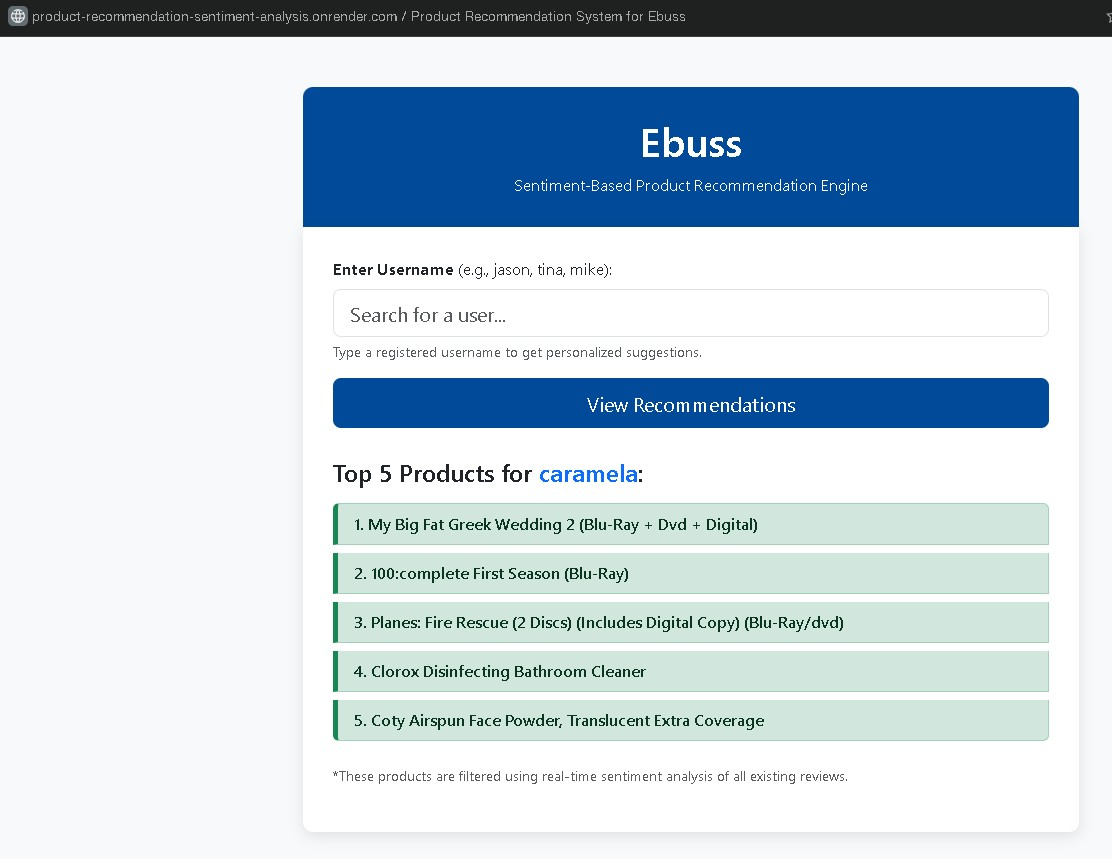

In [47]:
### Screen shot from the Public Webpage

from IPython.display import Image, display
display(Image(filename="webpage.jpg", width=800))

**Final Project Summary**

This project successfully delivers an end-to-end sentiment-aware recommendation engine.

1. Data Handling: Addressed missing values and class imbalance (SMOTE/Weighting).

2. ML Pipeline: Evaluated Logistic Regression, Random Forest, and XGBoost; Naive Bayes and Logistic Regression was selected for its balance of speed and F1-score.

3. Recommendation Logic: Compared User-User and Item-Item approaches; User-User was implemented due to superior RMSE.

4. Deployment: Optimized for cloud environments by using serialized dictionaries instead of raw matrices, ensuring a smooth user experience on the Flask web interface.

__________________

### **Conclusion & Future Scope**

The Ebuss Recommendation System successfully integrates Collaborative Filtering with Sentiment Analysis to ensure that recommended products are not only relevant to the user's history but are also highly regarded by the broader community.

**Key Achievements:**

1. Successfully handled class imbalance in review data.

2. Optimized a heavy ML pipeline to run on restricted cloud hardware.

3. Implemented a modular cleaning pipeline for consistent text processing.

**Future Scope:**

1. Hybrid Filtering: Incorporating Content-Based filtering to recommend items to brand-new users (solving the "Cold Start" problem).

2. Deep Learning: Using LSTM or BERT models to capture deeper contextual meaning in user reviews.

3. Real-time Feedback Loop: Updating the recommendation dictionary dynamically as soon as a user provides a new rating.

_____________________

*************** *END OF DOCUMENT*****************